In [ ]:
!pip install gradio

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1


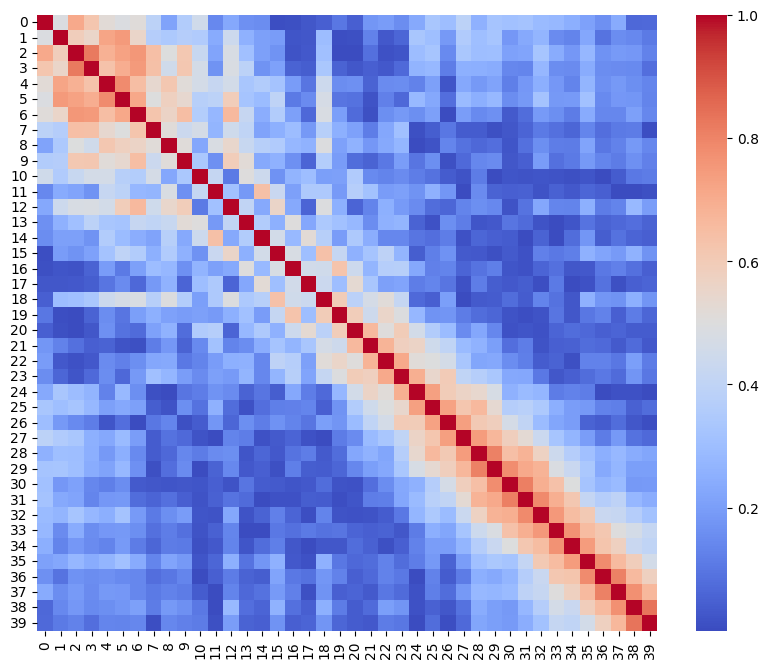

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2154 - loss: 1.9961 - val_accuracy: 0.2483 - val_loss: 1.8863
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3406 - loss: 1.7654 - val_accuracy: 0.3108 - val_loss: 1.7656
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3916 - loss: 1.6386 - val_accuracy: 0.3941 - val_loss: 1.6155
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4267 - loss: 1.4946 - val_accuracy: 0.4306 - val_loss: 1.4979
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5379 - loss: 1.2965 - val_accuracy: 0.4809 - val_loss: 1.3666
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5642 - loss: 1.2123 - val_accuracy: 0.5608 - val_loss: 1.2818
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6321 - loss: 1.0333 - val_accuracy: 0.6302 - val_loss: 1.0768
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6899 - loss: 0.9099 - val_accuracy: 0.5677 - va

In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, LSTM


# Load RAVDESS Dataset
dataset_path = path
file_paths = []
labels = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_paths.append(os.path.join(root, file))
            labels.append(file.split("-")[2])  # Extract emotion label from filename

# Convert labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
y_categorical = to_categorical(y_encoded)

# Feature Extraction using Librosa
features = []
for file in file_paths:
    y, sr = librosa.load(file, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfccs = np.mean(mfccs, axis=1)  # Take mean across time axis
    features.append(mfccs)

# Convert features to DataFrame
feature_df = pd.DataFrame(features)
feature_df['Emotion'] = labels

# EDA: Correlation Matrix
corr_matrix = feature_df.drop("Emotion", axis=1).corr().abs()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

# Feature Selection: Remove highly correlated features
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
feature_df_selected = feature_df.drop(columns=to_drop)

# Prepare data for CNN-LSTM
X = np.array(feature_df_selected.drop("Emotion", axis=1))
X = X.reshape(X.shape[0], X.shape[1], 1)  # Reshape for CNN-LSTM

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Build Hybrid CNN-LSTM Model
model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu", input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    LSTM(64, return_sequences=False),

    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(y_train.shape[1], activation="softmax")
])

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Hybrid CNN-LSTM Accuracy: {accuracy:.2f}")


In [ ]:


import gradio as gr
import torch
from transformers import pipeline

# Emotion Mapping
emotion_map = {
    0: "Neutral",
    1: "Calm",
    2: "Happy",
    3: "Sad",
    4: "Angry",
    5: "Fearful",
    6: "Disgust",
    7: "Surprised"
}


# Gradio Interface for Custom Audio Prediction
def predict_emotion(audio_file):
    y, sr = librosa.load(audio_file, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfccs = np.mean(mfccs, axis=1)
    mfccs = mfccs.reshape(1, -1, 1)

    prediction = model.predict(mfccs)
    predicted_label = np.argmax(prediction)
    predicted_emotion = emotion_map.get(predicted_label, "Unknown")

    return f"Predicted Emotion: {predicted_emotion}"
# Create Gradio Interface
interface = gr.Interface(
    fn=predict_emotion,  # Function to call
    inputs=gr.Audio(type="filepath"), # Input component
    outputs="text"  # Output component
)
interface.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://edd2943898d885bae2.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
